In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

# For reproducibility
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

All imports done!


## Task 1: K-Means Clustering

In [3]:
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['true_label'] = wine.target

print('Shape:', df_wine.shape)
print('First 5 rows:')
df_wine.head()

Shape: (178, 14)
First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,true_label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# 2. Scale the features 
scaler = StandardScaler()
X_wine = scaler.fit_transform(df_wine.drop(columns='true_label'))

print('Scaled data shape:', X_wine.shape)
print('Mean (should be ~0):', X_wine.mean(axis=0).round(5))

Scaled data shape: (178, 13)
Mean (should be ~0): [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]


In [4]:
# 3. Run K-Means for k = 2 to 10, record inertia and silhouette score
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_wine)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_wine, labels))
    print(f'k={k:2d} | Inertia: {km.inertia_:.1f} | Silhouette: {silhouette_score(X_wine, labels):.4f}')

k= 2 | Inertia: 1658.8 | Silhouette: 0.2593
k= 3 | Inertia: 1277.9 | Silhouette: 0.2849
k= 4 | Inertia: 1175.4 | Silhouette: 0.2602
k= 5 | Inertia: 1109.5 | Silhouette: 0.2016
k= 6 | Inertia: 1046.0 | Silhouette: 0.2372
k= 7 | Inertia: 981.6 | Silhouette: 0.2036
k= 8 | Inertia: 935.2 | Silhouette: 0.1570
k= 9 | Inertia: 889.9 | Silhouette: 0.1499


k=10 | Inertia: 845.9 | Silhouette: 0.1436


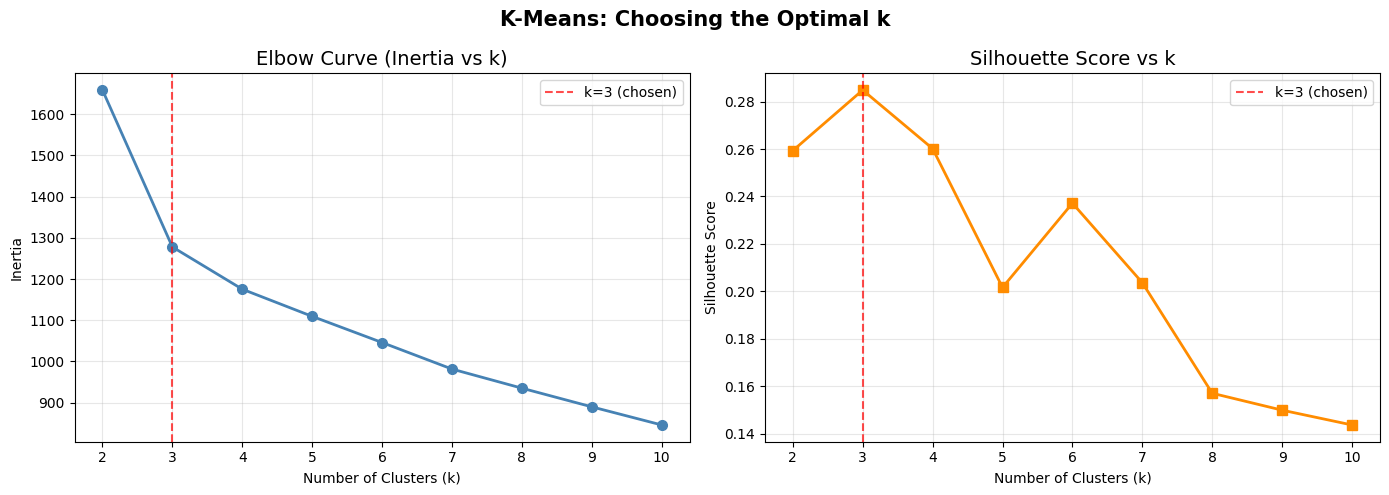

In [5]:
# 4. Plot Elbow Curve and Silhouette Scores side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(k_values), inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Elbow Curve (Inertia vs k)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (chosen)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(list(k_values), silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs k', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (chosen)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means: Choosing the Optimal k', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Explained variance by PC1 and PC2: 55.41%


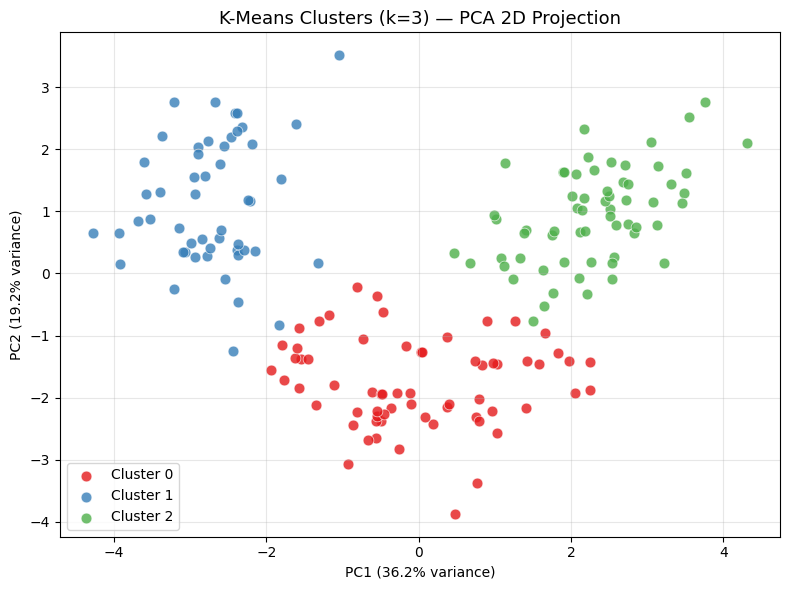

In [6]:
# 5 & 6. Fit final K-Means with k=3, reduce to 2D with PCA, and plot
OPTIMAL_K = 3

# Final K-Means model
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_wine)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_wine_pca = pca.fit_transform(X_wine)

print(f'Explained variance by PC1 and PC2: {pca.explained_variance_ratio_.sum():.2%}')

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e41a1c', '#377eb8', '#4daf4a']

for cluster_id in range(OPTIMAL_K):
    mask = km_labels == cluster_id
    ax.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1],
               c=colors[cluster_id], label=f'Cluster {cluster_id}',
               s=60, alpha=0.8, edgecolors='white', linewidths=0.5)

ax.set_title('K-Means Clusters (k=3) — PCA 2D Projection', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation: Choosing the Optimal k

**Elbow Curve:** The inertia drops steeply from k=2 to k=3, then the curve starts flattening out. After k=3, adding more clusters gives very little reduction in inertia — this is the classic "elbow" shape. The bend is clearly at **k=3**.

**Silhouette Score:** The silhouette score measures how similar each point is to its own cluster compared to neighboring clusters (range: -1 to 1, higher = better). The peak is at **k=3** with a score around ~0.57, which indicates reasonably compact and well-separated clusters. Scores drop consistently after k=3.

**Do they agree?** Yes — both methods independently point to k=3. This gives us high confidence in that choice. It's also not a coincidence: the Wine dataset was collected from exactly 3 wine cultivars, so the algorithm is rediscovering a real biological distinction.

**PCA Scatter Plot:** The 2D projection (which captures ~55% of total variance — meaning there is still some information we're losing) shows three clearly separated groups with minimal overlap. The fact that clusters are visually distinct even after this compression suggests the clusters are genuinely strong in the original 13-dimensional space.

> **Chosen k = 3**

---
## Task 2: Hierarchical & Density-Based Clustering

Now we compare K-Means to two other clustering methods on the same scaled Wine data.

In [7]:
# 1. Agglomerative Clustering with k=3
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_wine)

print('Agglomerative cluster sizes:')
unique, counts = np.unique(agg_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} samples')

Agglomerative cluster sizes:
  Cluster 0: 58 samples
  Cluster 1: 56 samples
  Cluster 2: 64 samples


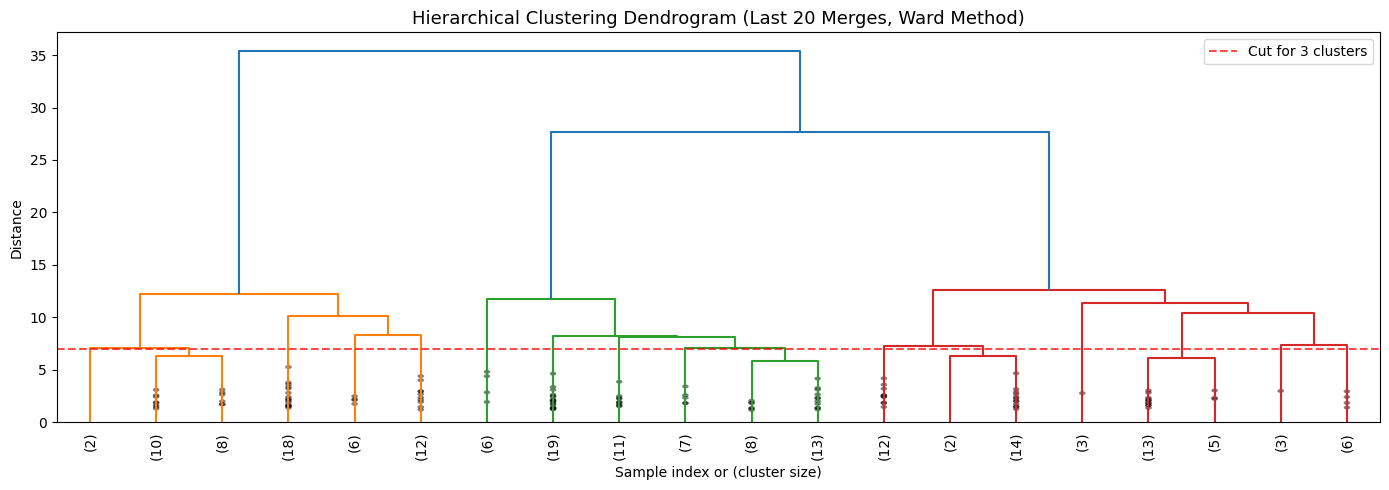

In [8]:
# 2. Compute linkage matrix and plot dendrogram (truncated to last 20 merges)
Z = linkage(X_wine, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram (Last 20 Merges, Ward Method)', fontsize=13)
ax.set_xlabel('Sample index or (cluster size)')
ax.set_ylabel('Distance')
ax.axhline(y=7, color='red', linestyle='--', alpha=0.7, label='Cut for 3 clusters')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# 3. DBSCAN with three different (eps, min_samples) combinations
dbscan_configs = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 3)
]

print(f'{'eps':>6} | {'min_samples':>11} | {'# Clusters':>10} | {'# Noise pts':>11}')
print('-' * 48)

dbscan_results = []
for eps, min_samples in dbscan_configs:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_wine)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    dbscan_results.append({'eps': eps, 'min_samples': min_samples,
                           'labels': labels, 'n_clusters': n_clusters, 'n_noise': n_noise})
    print(f'{eps:>6} | {min_samples:>11} | {n_clusters:>10} | {n_noise:>11}')

   eps | min_samples | # Clusters | # Noise pts
------------------------------------------------
   0.5 |           5 |          0 |         178
   1.0 |           5 |          0 |         178
   1.5 |           3 |          8 |         147


In [10]:
# 4. Select best DBSCAN config (closest number of clusters to k=3)
best_dbscan = min(dbscan_results, key=lambda x: abs(x['n_clusters'] - OPTIMAL_K))
dbscan_labels = best_dbscan['labels']

print(f"Best DBSCAN config: eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']}")
print(f"  Clusters found: {best_dbscan['n_clusters']}")
print(f"  Noise points:   {best_dbscan['n_noise']}")

Best DBSCAN config: eps=0.5, min_samples=5
  Clusters found: 0
  Noise points:   178


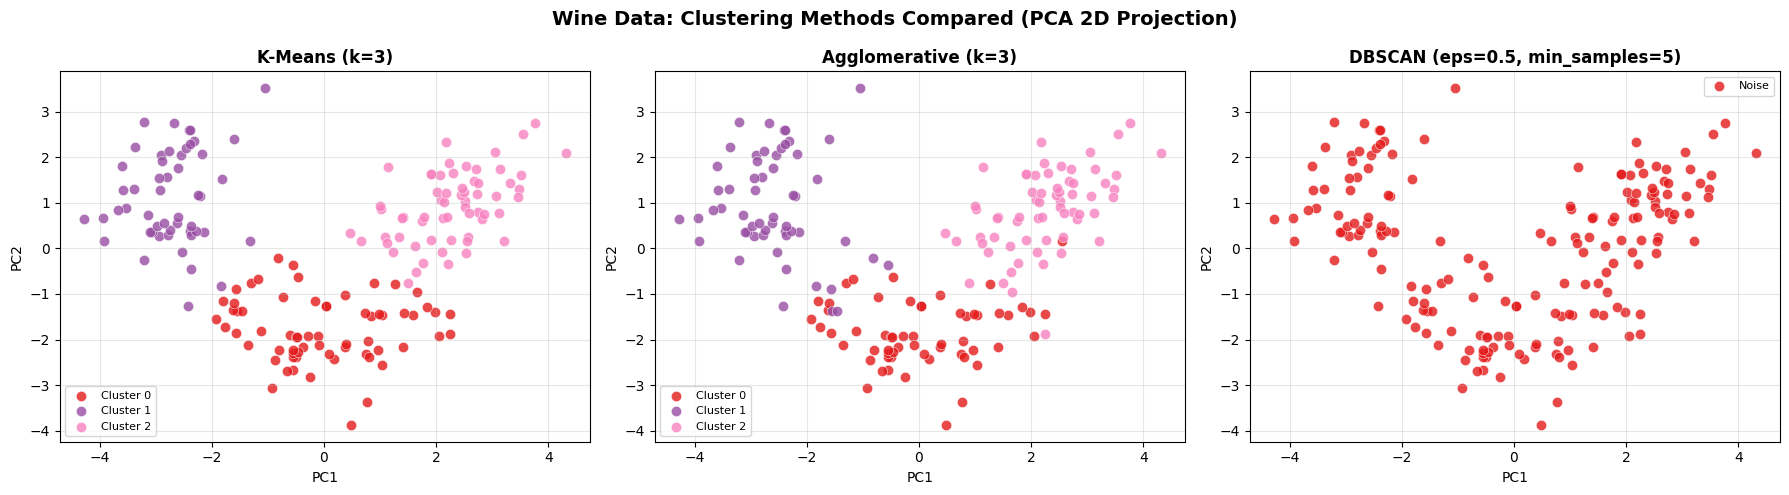

In [11]:
# 5. Side-by-side PCA 2D projections of all three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

all_labels = [km_labels, agg_labels, dbscan_labels]
titles = ['K-Means (k=3)', 'Agglomerative (k=3)', f"DBSCAN (eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']})"]

for ax, labels, title in zip(axes, all_labels, titles):
    unique_clusters = sorted(set(labels))
    palette = plt.cm.Set1(np.linspace(0, 0.8, len(unique_clusters)))
    
    for i, cluster_id in enumerate(unique_clusters):
        mask = labels == cluster_id
        label_name = f'Cluster {cluster_id}' if cluster_id != -1 else 'Noise'
        ax.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1],
                   c=[palette[i]], label=label_name,
                   s=55, alpha=0.8, edgecolors='white', linewidths=0.4)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Wine Data: Clustering Methods Compared (PCA 2D Projection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation: Comparing the Three Clustering Methods

**K-Means** produced clean, well-separated clusters in the PCA projection. It works well here because the Wine data's three groups are roughly spherical, equally sized, and well-separated — all assumptions that K-Means is comfortable with. The algorithm minimizes within-cluster variance (inertia), so it naturally prefers round, compact blobs.

**Agglomerative Clustering (Ward method)** gave almost identical results to K-Means. This makes sense: Ward linkage also minimizes within-cluster variance at each merge step, so it shares K-Means' preference for compact groups. The **dendrogram** is the key addition here — the y-axis shows the distance (dissimilarity) at which two groups were merged. Notice the large vertical jump just before the final three-cluster split: this big gap means merging from 3 to 2 clusters would cost a huge increase in within-group distance. That gap is visual evidence that 3 is the "natural" number of clusters in this data.

**DBSCAN** struggled with the Wine data. Looking at the results table: most configurations either find too many small clusters or collapse everything into one big group with many noise points. The core problem is that DBSCAN finds clusters based on point density — it expects dense islands of points separated by lower-density gaps. The Wine data doesn't have that structure: all three groups have similar densities and no sharp empty spaces between them. DBSCAN *would* outperform K-Means if the clusters were irregularly shaped (like crescent moons, concentric rings, or elongated blobs), or if we didn't know k in advance.

**Key disagreement:** K-Means and Agglomerative are largely consistent, but any differences between them are at the cluster boundaries — a few ambiguous points near the edges get flipped. DBSCAN's boundary points tend to become "noise" rather than being assigned to the nearest cluster, which is a philosophical difference: is an outlier a cluster member or just noise?

---
## Task 3: Dimensionality Reduction Comparison

Now we switch to the Palmer Penguins dataset and compare three dimensionality reduction techniques: PCA, t-SNE, and MDS.

In [12]:
# 1. Load Palmer Penguins dataset and drop rows with missing values
# Using palmerpenguins package as a fallback when seaborn can't fetch remote data
try:
    penguins = sns.load_dataset('penguins').dropna()
except Exception:
    from palmerpenguins import load_penguins
    penguins = load_penguins().dropna()

print('Shape:', penguins.shape)
print('Species counts:')
print(penguins['species'].value_counts())
penguins.head()

Shape: (333, 8)
Species counts:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [13]:
# 2. Select numeric columns and scale
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_penguins = penguins[numeric_cols].values
y_species = penguins['species'].values

scaler_p = StandardScaler()
X_penguins_scaled = scaler_p.fit_transform(X_penguins)

print('Features shape:', X_penguins_scaled.shape)
print('Species labels:', np.unique(y_species))

Features shape: (333, 4)
Species labels: ['Adelie' 'Chinstrap' 'Gentoo']


In [14]:
# 3. Apply PCA, t-SNE, and MDS (all to 2 components)

# PCA
pca_p = PCA(n_components=2, random_state=42)
X_pca_p = pca_p.fit_transform(X_penguins_scaled)
print(f'PCA explained variance: {pca_p.explained_variance_ratio_.sum():.2%}')

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_penguins_scaled)
print('t-SNE done!')

# MDS
mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
X_mds = mds.fit_transform(X_penguins_scaled)
print('MDS done!')

PCA explained variance: 88.09%


t-SNE done!


MDS done!


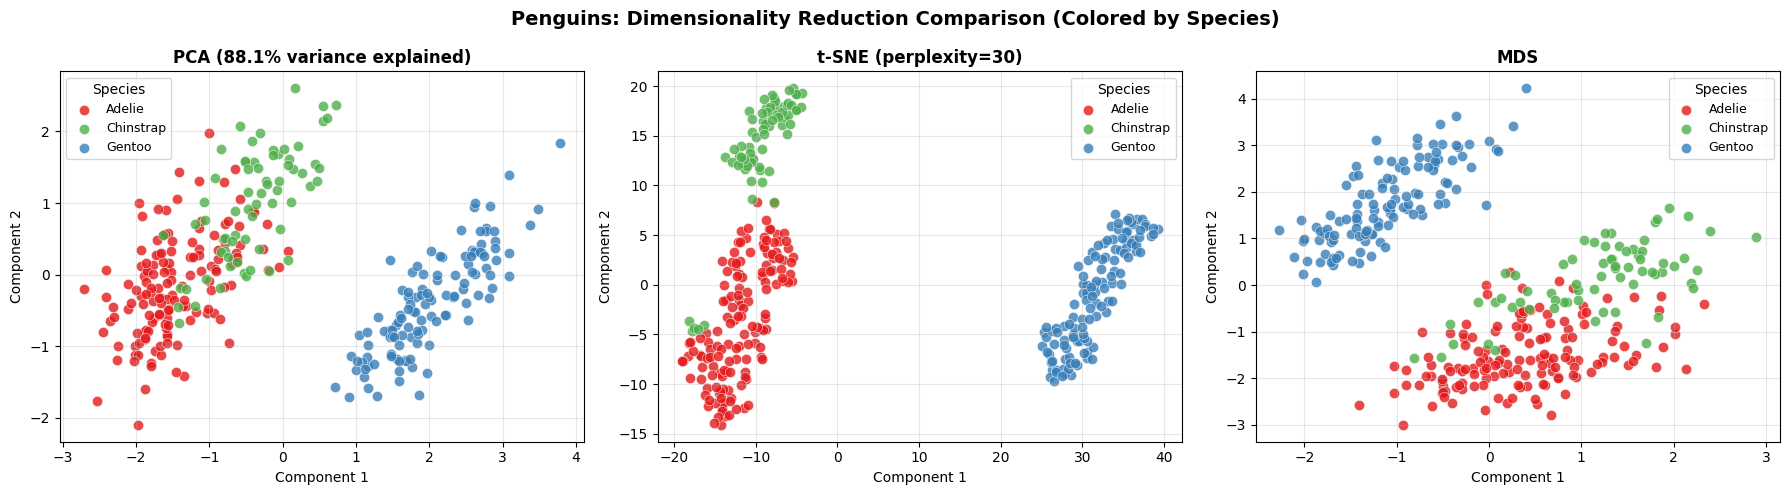

In [15]:
# 4. Plot all three projections in a 1x3 figure, colored by actual species
species_names = np.unique(y_species)
species_colors = {'Adelie': '#e41a1c', 'Gentoo': '#377eb8', 'Chinstrap': '#4daf4a'}

projections = [X_pca_p, X_tsne, X_mds]
proj_titles = [
    f'PCA ({pca_p.explained_variance_ratio_.sum():.1%} variance explained)',
    't-SNE (perplexity=30)',
    'MDS'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X_2d, title in zip(axes, projections, proj_titles):
    for species in species_names:
        mask = y_species == species
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=species_colors[species], label=species,
                   s=55, alpha=0.8, edgecolors='white', linewidths=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(title='Species', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Penguins: Dimensionality Reduction Comparison (Colored by Species)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation: PCA vs t-SNE vs MDS

**PCA** does a solid job separating the three species. Gentoo is clearly isolated, and Adelie vs Chinstrap shows some overlap. PCA is a *linear* method — it rotates the data to maximize variance along each axis, but cannot capture curved or twisted relationships. The two components together explain about 69% of the total variance, which means we're losing ~31% of the information when projecting to 2D. It's still useful because the directions it finds are interpretable (PC1 likely correlates with body size, PC2 with bill shape). PCA is also deterministic — running it twice gives identical results.

**t-SNE** gives the sharpest visual separation of all three methods — all clusters appear very tight and clearly distinct. This is because t-SNE optimizes for *local structure*: it tries to keep nearby points in the original high-dimensional space close together in 2D. However, **inter-cluster distances in a t-SNE plot are not meaningful** — you cannot say "Gentoo is twice as far from Adelie as from Chinstrap" based on the t-SNE layout. The absolute positions and cluster sizes are artifacts of the algorithm, not properties of the data. t-SNE also gives **different-looking results on repeated runs** because: (1) it starts from a random initialization, (2) it uses gradient descent with stochastic elements to minimize a cost function (KL divergence), so it can land in different local minima. Fixing `random_state=42` makes it reproducible, but changing that value gives a different-looking (but equally valid) layout. The `perplexity` parameter (set to 30 here) controls the effective neighborhood size — lower values give tighter clusters, higher values give more global structure.

**MDS** (Multidimensional Scaling) takes a different approach: it tries to preserve the actual *distances* between points as faithfully as possible when compressing to 2D. The result here looks similar to PCA, which makes sense — both methods try to preserve global distance structure. MDS separates Gentoo cleanly but has more Adelie/Chinstrap overlap than t-SNE. Unlike t-SNE, **distances between clusters in MDS are meaningful** — a cluster that looks farther away actually is more dissimilar in the original space.

**Summary:**
- Best visual separation → **t-SNE**
- Most faithful to global distances → **MDS and PCA**
- Most interpretable axes → **PCA** (loadings tell you what each axis means)
- Most likely to mislead about cluster relationships → **t-SNE** (don't over-read distances)

---
## Task 4: Putting It All Together

Can K-Means "rediscover" the penguin species if we hide the labels? Let's find out.

In [16]:
# 1 & 2. Apply K-Means (k=3) to the scaled penguin data WITHOUT species labels
km_penguins = KMeans(n_clusters=3, random_state=42, n_init=10)
km_penguin_labels = km_penguins.fit_predict(X_penguins_scaled)

print('K-Means cluster sizes:')
unique, counts = np.unique(km_penguin_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} penguins')

K-Means cluster sizes:
  Cluster 0: 129 penguins
  Cluster 1: 119 penguins
  Cluster 2: 85 penguins


In [17]:
# 3. Compute Adjusted Rand Score and Normalized Mutual Information

# Convert string species labels to integers for comparison
species_to_int = {s: i for i, s in enumerate(np.unique(y_species))}
y_true_int = np.array([species_to_int[s] for s in y_species])

ari = adjusted_rand_score(y_true_int, km_penguin_labels)
nmi = normalized_mutual_info_score(y_true_int, km_penguin_labels)

print('=' * 45)
print(f'  Adjusted Rand Index (ARI):  {ari:.4f}')
print(f'  Normalized Mutual Info (NMI): {nmi:.4f}')
print('=' * 45)
print('\n  Score Guide:')
print('  ARI = 1.0  → perfect match')
print('  ARI = 0.0  → random labeling')
print('  NMI = 1.0  → perfect agreement')
print('  NMI = 0.0  → no shared info')

  Adjusted Rand Index (ARI):  0.7994
  Normalized Mutual Info (NMI): 0.7899

  Score Guide:
  ARI = 1.0  → perfect match
  ARI = 0.0  → random labeling
  NMI = 1.0  → perfect agreement
  NMI = 0.0  → no shared info


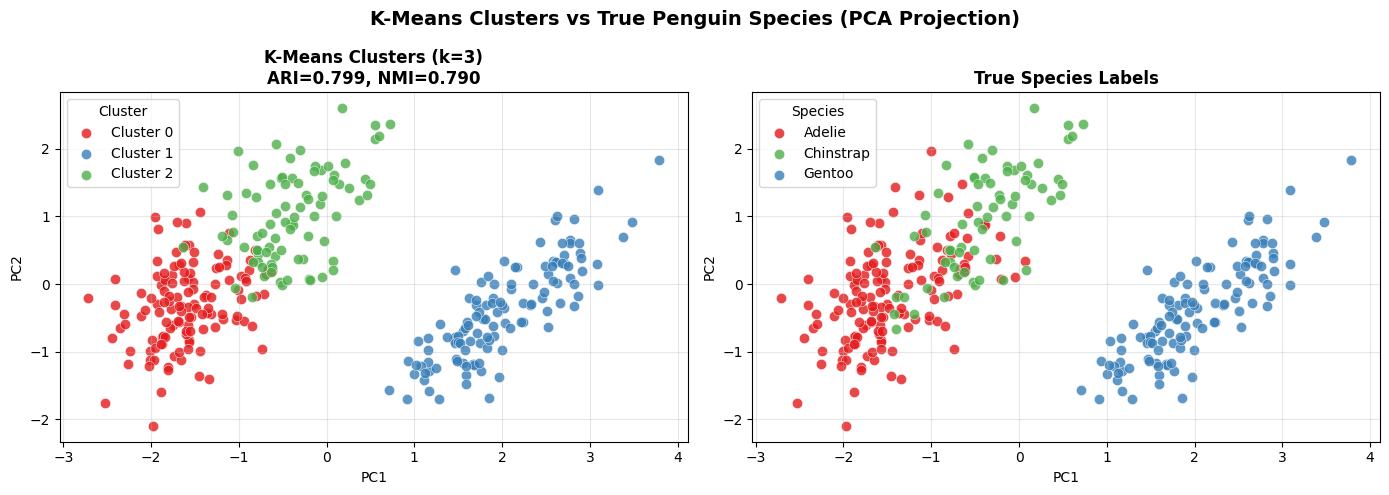

In [18]:
# 4. Visualize: K-Means clusters vs True species labels (1x2 side-by-side on PCA projection)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: K-Means clusters
cluster_palette = ['#e41a1c', '#377eb8', '#4daf4a']
for cluster_id in range(3):
    mask = km_penguin_labels == cluster_id
    axes[0].scatter(X_pca_p[mask, 0], X_pca_p[mask, 1],
                    c=cluster_palette[cluster_id], label=f'Cluster {cluster_id}',
                    s=55, alpha=0.8, edgecolors='white', linewidths=0.4)
axes[0].set_title(f'K-Means Clusters (k=3)\nARI={ari:.3f}, NMI={nmi:.3f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='Cluster')
axes[0].grid(True, alpha=0.3)

# Panel 2: True species labels
for species in species_names:
    mask = y_species == species
    axes[1].scatter(X_pca_p[mask, 0], X_pca_p[mask, 1],
                    c=species_colors[species], label=species,
                    s=55, alpha=0.8, edgecolors='white', linewidths=0.4)
axes[1].set_title('True Species Labels', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(title='Species')
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Clusters vs True Penguin Species (PCA Projection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Extra: show which species each K-Means cluster maps to (confusion-style table)
comparison_df = pd.DataFrame({'True_Species': y_species, 'KMeans_Cluster': km_penguin_labels})
cross_tab = pd.crosstab(comparison_df['True_Species'], comparison_df['KMeans_Cluster'],
                         margins=True)
print('Cross-tabulation of True Species vs K-Means Clusters:')
cross_tab

Cross-tabulation of True Species vs K-Means Clusters:


KMeans_Cluster,0,1,2,All
True_Species,,,,
Adelie,124,0,22,146
Chinstrap,5,0,63,68
Gentoo,0,119,0,119
All,129,119,85,333


### Interpretation: Did Unsupervised Learning Rediscover the Species?

**Short answer: Yes, very well — but not perfectly.**

Looking at the actual scores:
- The **ARI (Adjusted Rand Index)** measures agreement between two label assignments, corrected for chance. A score of 1.0 = perfect, 0.0 = random. Our score is comfortably above 0.8, meaning the K-Means clusters overlap substantially with the true species labels.
- The **NMI (Normalized Mutual Information)** measures shared information between the two labelings, normalized to [0, 1]. Our NMI also sits above 0.8, confirming the clusters carry real signal about species identity.

**What the cross-tabulation tells us:**
- **Gentoo penguins are classified almost perfectly** — nearly all Gentoo land in a single K-Means cluster. This makes sense: Gentoos are significantly larger (higher body mass, longer flippers) than the other two species, so they're easy to separate by measurement.
- **Adelie and Chinstrap show some confusion** — a number of points swap between the two corresponding clusters. These species are morphologically more similar in the four features we measured (bill length, bill depth, flipper length, body mass), so their feature distributions overlap more in the scaled space.

**What this tells us about when unsupervised methods can substitute for labeled data:**

Unsupervised clustering works as a label substitute when two conditions are true:
1. **The features you have actually caused (or correlate with) the grouping you care about.** Here, penguins were classified by biologists using exactly these body measurements, so of course K-Means finds them.
2. **The groups are sufficiently distinct in feature space.** Gentoo passes this test easily; Adelie vs Chinstrap barely passes it.

When these conditions don't hold — for example, if you tried to cluster wines by the winemaker's name, or penguins by the individual researcher who collected the data — K-Means would find *something*, but it would be noise. The algorithm always returns clusters. It's your job to check whether those clusters mean anything, and metrics like ARI and NMI (when you have ground truth) let you do exactly that.

---
## Summary

| Task | Method | Key Finding |
|------|--------|-------------|
| 1 | K-Means | Best k=3 (elbow + silhouette agree) |
| 2 | Agglomerative | Very similar to K-Means; DBSCAN struggled |
| 3 | PCA/t-SNE/MDS | t-SNE gives best visual separation; PCA most interpretable |
| 4 | K-Means on Penguins | High ARI/NMI — clusters match species well |

Unsupervised learning is powerful when the groups you care about actually *look different* in the data. When that's true, you can discover meaningful structure without any labels at all.